# Aprendizaxe automático - Práctica 3

## Redes convolucionais

**Luis Barba Cepedello, Rubén Pérez Sangiao, Daniel Piqueras Valle**

## Implementación dunha arquitectura MLP modular

In [8]:
import torch
from torch import nn

# Clase que define un MLP xenérico
class MLP(nn.Module):
    def __init__(self, input_neurons, output_neurons, hidden_layers):
        # Parámetros:
        # input_neurons: Número de neuronas da capa de entrada
        # output_neurons: Número de neuronas da capa de saída
        # hidden_layers: Lista onde cada elemento representa o número de neuronas dunha capa oculta

        # Chamamos ao constructor da clase nai
        super(MLP, self).__init__()

        # Lista onde iremos engadindo cada unha das capas
        layers = []

        # O número de entradas da primeira capa é 'input_neurons'
        current_input = input_neurons

        # Iteramos sobre a lista de capas ocultas para construír a rede paso a paso
        for hidden_neurons in hidden_layers:
            # Engadimos a capa lineal
            layers.append(nn.Linear(in_features=current_input, out_features=hidden_neurons))

            # Engadimos a función de activación RELU (hai que ter en conta que non se aplica á última)
            layers.append(nn.ReLU())

            # A saída desta capa será a entrada da seguinte
            current_input = hidden_neurons

        # Unha vez engadidas todas as capas ocultas, engadimos a capa de saída
        layers.append(nn.Linear(in_features=current_input, out_features=output_neurons))

        # nn.Sequential permítenos empaquetar a lista de capas nun único módulo que as executará en orde secuencial cando se faga o forward
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # Definimos o método forward, que é chamado cando se pasa unha imaxe pola rede

        # Aplicamos o aplanamento
        x = torch.flatten(x, start_dim=1)

        # Pasamos os datos pola nosa secuencia de capas
        predicted_probs = self.network(x)
        return predicted_probs

## Implementación dunha arquitectura CNN modular

In [14]:
# Clase que define una Red Neuronal Convolucional (CNN) genérica.
class CNN(nn.Module):
    def __init__(self,
                 input_channels,
                 conv_layers,
                 first_conv_filters,
                 conv_kernel_size,
                 batch_norm,
                 hidden_mlp_layers,
                 output_neurons,
                 image_size=160): # Añadimos image_size (160x160 por defecto) para calcular el aplanado

        # Chamamos ao constructor da clase pai
        super(CNN, self).__init__()

        ### CONSTRUCIÓN DA PARTE CONVOLUCIONAL ###
        conv_modules = []
        in_c = input_channels
        out_c = first_conv_filters

        # Iteramos para crear as capas convolucionais
        for i in range(conv_layers):
            # Añadimos a capa convolucional
            # Empregamos o seguinte padding: conv_kernel_size // 2 para mantener as proporcións antes do pooling
            conv_modules.append(nn.Conv2d(in_channels=in_c,
                                          out_channels=out_c,
                                          kernel_size=conv_kernel_size,
                                          padding=conv_kernel_size // 2))

            # Normalización por lotes
            # Normalizamos antes de aplicar a ReLU, pero perfectamente podería facerse ao revés
            # Escollemos facelo así porque era o que recomendaban Sergey Ioffe e Christian Szegedy, os creadores da técnica
            if batch_norm:
                conv_modules.append(nn.BatchNorm2d(out_c))

            # Función de activación ReLU
            conv_modules.append(nn.ReLU())

            # Capa de Pooling
            # Asumimos un MaxPooling estándar de 2x2
            conv_modules.append(nn.MaxPool2d(kernel_size=2, stride=2))

            # Para a proxima capa a entrada son os filtros de salida actuales
            in_c = out_c
            # Doble número de filtros para a siguiente capa convolucional
            out_c *= 2

        self.conv_network = nn.Sequential(*conv_modules)

        ### CONSTRUCIÓN DA PARTE MLP ###
        # Creamos un tensor falso del tamaño de nuestras imágenes para pasarlo por la red convolucional
        # y así descubrir automáticamente cuántas características salen tras todos los MaxPoolings.
        dummy_tensor = torch.zeros(1, input_channels, image_size, image_size)
        dummy_output = self.conv_network(dummy_tensor)
        flattened_size = dummy_output.view(-1).shape[0]

        mlp_modules = []
        current_input = flattened_size

        # Iteramos sobre as capas ocultas do MLP
        for hidden_neurons in hidden_mlp_layers:
            mlp_modules.append(nn.Linear(in_features=current_input, out_features=hidden_neurons))
            mlp_modules.append(nn.ReLU())
            current_input = hidden_neurons

        # Capa final de salida (sin función de activación)
        mlp_modules.append(nn.Linear(in_features=current_input, out_features=output_neurons))

        self.mlp_network = nn.Sequential(*mlp_modules)

    def forward(self, x):
        x = self.conv_network(x)

        # Aplanado final unidimensional para pasarllo a un MLP
        x = torch.flatten(x, start_dim=1)
        x = self.mlp_network(x)

        return x

#

In [10]:
import torch
import copy

def train(dataloader, model, loss_fn, optimizer, device="cpu"):
    """Función xenérica para adestrar unha época."""
    model.train()
    running_loss = 0.0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)

    return running_loss / len(dataloader.dataset)

def evaluate(dataloader, model, loss_fn, device="cpu"):
    """Función xenérica para avaliar o modelo (Validación ou Test)."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fn(pred, y)

            running_loss += loss.item() * X.size(0)
            _, predicted = torch.max(pred, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

    val_loss = running_loss / total
    val_acc = (correct / total) * 100
    return val_loss, val_acc

## Adestramento e optimización de MLPs e CNNs nun problema real

In [11]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

# 1. Definimos las transformaciones para asegurar el tamaño exacto y convertir a tensores
# La versión '160px' de Imagenette redimensiona el lado más corto a 160,
# por lo que forzamos un CenterCrop o Resize exacto a 160x160.
transform = transforms.Compose([
    transforms.Resize((160, 160)), # Aseguramos dimensiones exactas de 160x160
    transforms.ToTensor(),         # Convierte la imagen a tensor y escala los valores a [0, 1]
    # Opcional: transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Descargando e importando los datos de Imagenette (160px)...")

# 2. Descargamos la partición 'train' original (9469 imágenes)
full_train_dataset = torchvision.datasets.Imagenette(
    root='./data',
    split='train',
    size='160px', # Pedimos la versión de baja resolución
    download=True,
    transform=transform
)

# 3. Descargamos la partición 'val' original (3925 imágenes), que usaremos para TEST
test_dataset = torchvision.datasets.Imagenette(
    root='./data',
    split='val',
    size='160px',
    download=True,
    transform=transform
)

# 4. Subdividimos la partición 'train' original en Entrenamiento y Validación
# Por ejemplo, podemos usar un 80% para entrenar y un 20% para validar
train_proportion = 0.8
train_size = int(train_proportion * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42) # Para que la partición sea reproducible
)

print(f"Total original 'train': {len(full_train_dataset)} imágenes.")
print(f"  -> Nuevo Entrenamiento: {len(train_dataset)} imágenes.")
print(f"  -> Nueva Validación: {len(val_dataset)} imágenes.")
print(f"Total original 'val' (usado como TEST): {len(test_dataset)} imágenes.")

# 5. Creamos los DataLoaders para el entrenamiento
batch_size = 32 # Puedes ajustar este valor según la memoria de tu GPU/CPU

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Comprobación de las dimensiones del tensor de un batch
imagenes, etiquetas = next(iter(train_loader))
print(f"Forma del tensor de imágenes (batch_size, canales, alto, ancho): {imagenes.shape}")

Descargando e importando los datos de Imagenette (160px)...
Total original 'train': 9469 imágenes.
  -> Nuevo Entrenamiento: 7575 imágenes.
  -> Nueva Validación: 1894 imágenes.
Total original 'val' (usado como TEST): 3925 imágenes.
Forma del tensor de imágenes (batch_size, canales, alto, ancho): torch.Size([32, 3, 160, 160])


In [12]:
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Adestrando no dispositivo: {device}")

# 1. Instanciamos o MLP (76800 entradas, 10 saídas)
mlp_model = MLP(input_neurons=76800, output_neurons=10, hidden_layers=[128, 64]).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer_mlp = optim.Adam(mlp_model.parameters(), lr=0.001)

# Variables para gardar o historial e Early Stopping
mlp_val_losses = []
mlp_val_accs = []
max_epochs = 30
patience = 5
best_val_loss = float('inf')
patience_counter = 0
best_mlp_wts = copy.deepcopy(mlp_model.state_dict())

print("--- Iniciando adestramento do MLP ---")
for epoch in range(max_epochs):
    # Adestramos e avaliamos
    train_loss = train(train_loader, mlp_model, loss_fn, optimizer_mlp, device)
    val_loss, val_acc = evaluate(val_loader, mlp_model, loss_fn, device)

    mlp_val_losses.append(val_loss)
    mlp_val_accs.append(val_acc)

    print(f"Época {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_mlp_wts = copy.deepcopy(mlp_model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"-> Parada temperá na época {epoch+1}!")
            break

# Restauramos os mellores pesos obtidos
mlp_model.load_state_dict(best_mlp_wts)
print("MLP adestrado e mellor modelo cargado.")

Adestrando no dispositivo: cuda
--- Iniciando adestramento do MLP ---
Época 01 | Train Loss: 2.2518 | Val Loss: 2.0048 | Val Acc: 30.36%
Época 02 | Train Loss: 1.9758 | Val Loss: 2.0411 | Val Acc: 29.09%
Época 03 | Train Loss: 1.9109 | Val Loss: 1.9460 | Val Acc: 32.42%
Época 04 | Train Loss: 1.8363 | Val Loss: 1.9655 | Val Acc: 33.47%
Época 05 | Train Loss: 1.7997 | Val Loss: 2.0189 | Val Acc: 31.89%
Época 06 | Train Loss: 1.7535 | Val Loss: 1.8546 | Val Acc: 37.65%
Época 07 | Train Loss: 1.6885 | Val Loss: 1.8324 | Val Acc: 39.81%
Época 08 | Train Loss: 1.6633 | Val Loss: 1.9863 | Val Acc: 35.69%
Época 09 | Train Loss: 1.6600 | Val Loss: 1.9215 | Val Acc: 36.91%
Época 10 | Train Loss: 1.6138 | Val Loss: 1.8372 | Val Acc: 38.91%
Época 11 | Train Loss: 1.5870 | Val Loss: 1.8659 | Val Acc: 38.17%
Época 12 | Train Loss: 1.5680 | Val Loss: 1.7907 | Val Acc: 39.28%
Época 13 | Train Loss: 1.5015 | Val Loss: 1.9064 | Val Acc: 37.70%
Época 14 | Train Loss: 1.4829 | Val Loss: 1.7917 | Val Acc:

In [15]:
# 1. Instanciamos a CNN
cnn_model = CNN(input_channels=3,
                conv_layers=3,
                first_conv_filters=16,
                conv_kernel_size=3,
                batch_norm=True,
                hidden_mlp_layers=[128],
                output_neurons=10,
                image_size=160).to(device)

optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

# Variables para gardar o historial e Early Stopping
cnn_val_losses = []
cnn_val_accs = []
best_val_loss = float('inf')
patience_counter = 0
best_cnn_wts = copy.deepcopy(cnn_model.state_dict())

print("--- Iniciando adestramento da CNN ---")
for epoch in range(max_epochs):
    train_loss = train(train_loader, cnn_model, loss_fn, optimizer_cnn, device)
    val_loss, val_acc = evaluate(val_loader, cnn_model, loss_fn, device)

    cnn_val_losses.append(val_loss)
    cnn_val_accs.append(val_acc)

    print(f"Época {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_cnn_wts = copy.deepcopy(cnn_model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"-> Parada temperá na época {epoch+1}!")
            break

cnn_model.load_state_dict(best_cnn_wts)
print("CNN adestrada e mellor modelo cargado.")

--- Iniciando adestramento da CNN ---
Época 01 | Train Loss: 2.2056 | Val Loss: 1.5804 | Val Acc: 47.31%
Época 02 | Train Loss: 1.3581 | Val Loss: 1.2764 | Val Acc: 59.03%
Época 03 | Train Loss: 1.1018 | Val Loss: 1.3333 | Val Acc: 57.39%
Época 04 | Train Loss: 0.9486 | Val Loss: 1.2130 | Val Acc: 62.51%
Época 05 | Train Loss: 0.7987 | Val Loss: 1.2881 | Val Acc: 59.45%
Época 06 | Train Loss: 0.6904 | Val Loss: 1.1924 | Val Acc: 63.31%
Época 07 | Train Loss: 0.5364 | Val Loss: 1.2841 | Val Acc: 62.30%
Época 08 | Train Loss: 0.4450 | Val Loss: 1.3731 | Val Acc: 62.30%
Época 09 | Train Loss: 0.3361 | Val Loss: 1.6238 | Val Acc: 60.24%
Época 10 | Train Loss: 0.2371 | Val Loss: 1.5682 | Val Acc: 62.25%
Época 11 | Train Loss: 0.1939 | Val Loss: 1.5108 | Val Acc: 65.68%
-> Parada temperá na época 11!
CNN adestrada e mellor modelo cargado.


 RESULTADOS FINAIS NO CONXUNTO DE TEST
MLP -> Test Loss: 1.7884 | Accuracy: 39.64%
CNN -> Test Loss: 1.1587 | Accuracy: 65.15%

Parámetros do MLP: 9,839,434
Parámetros da CNN: 3,302,026



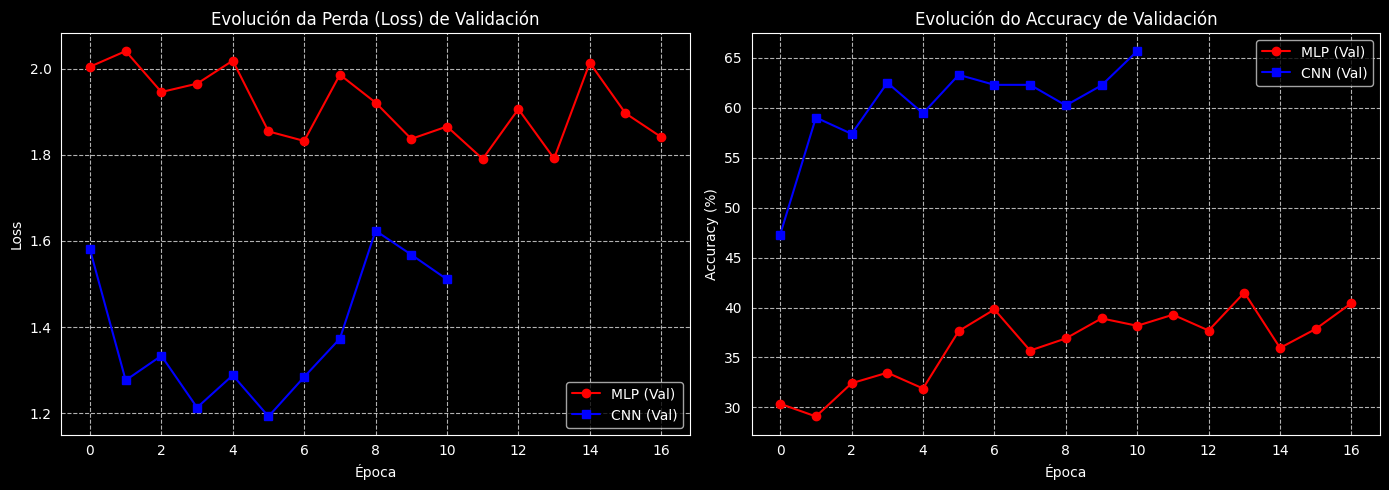

In [16]:
import matplotlib.pyplot as plt

# --- 1. AVALIACIÓN NO CONXUNTO DE TEST ---
print("="*50)
print(" RESULTADOS FINAIS NO CONXUNTO DE TEST")
print("="*50)

# Avaliamos usando a función xenérica do principio da práctica
test_loss_mlp, test_acc_mlp = evaluate(test_loader, mlp_model, loss_fn, device)
test_loss_cnn, test_acc_cnn = evaluate(test_loader, cnn_model, loss_fn, device)

print(f"MLP -> Test Loss: {test_loss_mlp:.4f} | Accuracy: {test_acc_mlp:.2f}%")
print(f"CNN -> Test Loss: {test_loss_cnn:.4f} | Accuracy: {test_acc_cnn:.2f}%\n")


# --- 2. CÁLCULO DE COMPLEXIDADE ---
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params_mlp = count_parameters(mlp_model)
params_cnn = count_parameters(cnn_model)

print(f"Parámetros do MLP: {params_mlp:,}")
print(f"Parámetros da CNN: {params_cnn:,}\n")


# --- 3. GRÁFICAS COMPARATIVAS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Loss
ax1.plot(mlp_val_losses, label='MLP (Val)', color='red', marker='o')
ax1.plot(cnn_val_losses, label='CNN (Val)', color='blue', marker='s')
ax1.set_title('Evolución da Perda (Loss) de Validación')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfica de Accuracy
ax2.plot(mlp_val_accs, label='MLP (Val)', color='red', marker='o')
ax2.plot(cnn_val_accs, label='CNN (Val)', color='blue', marker='s')
ax2.set_title('Evolución do Accuracy de Validación')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()